# **Dataset Final - Tratamento Adequado e Filtros (WIP)**

In [6]:
%%capture
%run "/workspaces/CEA-1/análise de dados/tratamento_das_variaveis_explicativas.ipynb"

Colocar as colunas que já estão tratadas e prontas para serem analisadas

    'dor_abdominal', 'dor_no_corpo', 'artralgia', 'cefaleia', 'dor',
    'exantema_local', 'exantema', 'edema', 'eritema', 'calor', 'enduracao',
    'abscesso_quente', 'lesao', 'linfonodomegalia', 'prurido', 'febre',
    'nausea', 'emese', 'diarreia', 'tontura', 'sincope', 'parestesia',
    'convulsao', 'confusao_mental', 'fraqueza', 'hipotensao', 'taquicardia',
    'bradicardia', 'extremidades_frias', 'palidez', 'sudorese', 'urticaria',
    'broncoespasmo', 'dispneia', 'angioedema', 'tremor', 'fotofobia',
    'visao_turva', 'guillain_barre', 'encefalite', 'epilepsia', 'paralisia',
    'purpura_trombocitopenica', 'manifestacoes_locais', 'manifestacoes_sistemicas'

In [7]:
coluna_resposta = ['cls_fin_ajustada']

colunas_explicativas = ['dt_not_ano', 'regiao', 'pais_nasc', 'sexo', 'cor', 'gestante',
            'cod_prod_ajustada', 'dt_apl_ano', 'dose_ajustada', 'via_adm_ajustada', 'local_aplic_ajustada', 'tp_med', 'cls_ei_ajustada',  'tp_atd_ajustada', 
            'cls_eien',  'idade_anos', 'evol_num', 'dor_abdominal', 'dor_no_corpo', 'artralgia', 'cefaleia', 'dor',
    'exantema_local', 'exantema', 'edema', 'eritema', 'calor', 'enduracao',
    'abscesso_quente', 'lesao', 'linfonodomegalia', 'prurido', 'febre',
    'nausea', 'emese', 'diarreia', 'tontura', 'sincope', 'parestesia',
    'convulsao', 'confusao_mental', 'fraqueza', 'hipotensao', 'taquicardia',
    'bradicardia', 'extremidades_frias', 'palidez', 'sudorese', 'urticaria',
    'broncoespasmo', 'dispneia', 'angioedema', 'tremor', 'fotofobia',
    'visao_turva', 'guillain_barre', 'encefalite', 'epilepsia', 'paralisia',
    'purpura_trombocitopenica', 'manifestacoes_locais', 'manifestacoes_sistemicas']

dados_finais = dados[coluna_resposta + colunas_explicativas]
print(dados_finais.columns.tolist())
print(f"Dimensões: {dados_finais.shape[0]} linhas × {dados_finais.shape[1]} colunas")

['cls_fin_ajustada', 'dt_not_ano', 'regiao', 'pais_nasc', 'sexo', 'cor', 'gestante', 'cod_prod_ajustada', 'dt_apl_ano', 'dose_ajustada', 'via_adm_ajustada', 'local_aplic_ajustada', 'tp_med', 'cls_ei_ajustada', 'tp_atd_ajustada', 'cls_eien', 'idade_anos', 'evol_num', 'dor_abdominal', 'dor_no_corpo', 'artralgia', 'cefaleia', 'dor', 'exantema_local', 'exantema', 'edema', 'eritema', 'calor', 'enduracao', 'abscesso_quente', 'lesao', 'linfonodomegalia', 'prurido', 'febre', 'nausea', 'emese', 'diarreia', 'tontura', 'sincope', 'parestesia', 'convulsao', 'confusao_mental', 'fraqueza', 'hipotensao', 'taquicardia', 'bradicardia', 'extremidades_frias', 'palidez', 'sudorese', 'urticaria', 'broncoespasmo', 'dispneia', 'angioedema', 'tremor', 'fotofobia', 'visao_turva', 'guillain_barre', 'encefalite', 'epilepsia', 'paralisia', 'purpura_trombocitopenica', 'manifestacoes_locais', 'manifestacoes_sistemicas']
Dimensões: 1083 linhas × 63 colunas


In [8]:
#nome_do_ficheiro = 'dados_completos.csv'

## O parâmetro index=False evita que o pandas crie uma coluna extra com os números das linhas
#dados_finais.to_csv(nome_do_ficheiro, index=False, encoding='utf-8')

Frequência da Variável Resposta:
cls_fin_ajustada
EANG                   48.85%
EI                     45.98%
EAG                     4.06%
Inclassificável         0.74%
EI - evento adverso     0.37%
Name: proportion, dtype: str



RANKING DE ASSOCIAÇÃO COM A RESPOSTA (V DE CRAMER)
                Variável  V de Cramer       P-Valor
manifestacoes_sistemicas     0.754507 4.094255e-132
                  tp_med     0.566549 7.581774e-145
    manifestacoes_locais     0.565385  1.164588e-73
         tp_atd_ajustada     0.521134 7.881649e-122
         cls_ei_ajustada     0.507252 1.272376e-210
               convulsao     0.462922  4.699706e-49
                     dor     0.421991  1.289096e-40
                cls_eien     0.402585 1.910786e-124
                 eritema     0.373313  1.286604e-31
          guillain_barre     0.352408  4.245920e-28
                   edema     0.352358  4.326824e-28
                   febre     0.328257  2.711142e-24
                cefaleia     0.327086  4.079554e-24
                   emese     0.317405  1.127693e-22
                 sincope     0.299854  3.560514e-20
                 palidez     0.296984  8.834509e-20
                   calor     0.292182  3.959634e-19
            

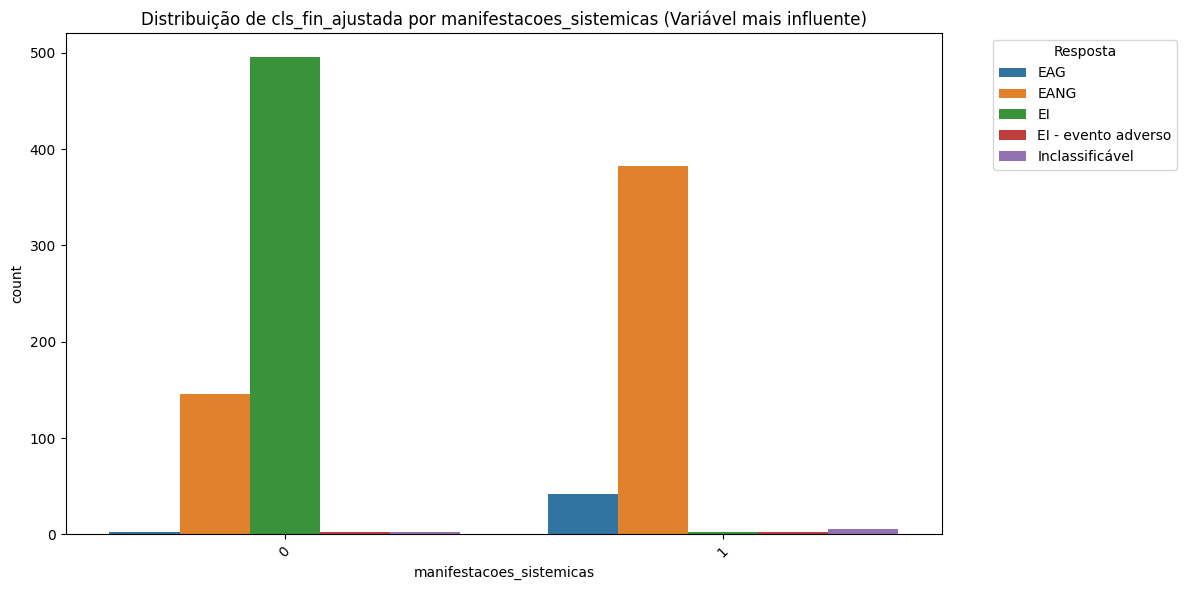

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ── 1. DEFINIÇÃO DAS COLUNAS ──────────────────────────────────────────────────
coluna_resposta = 'cls_fin_ajustada'


# Criar cópia para análise
df_analise = dados_finais.copy()

# ── 2. TRANSFORMAÇÃO PARA CATEGÓRICAS ─────────────────────────────────────────
# Convertemos para string primeiro para garantir que códigos numéricos sejam tratados como labels
for col in df_analise.columns:
    df_analise[col] = df_analise[col].astype(str).astype('category')

print("Frequência da Variável Resposta:")
print(df_analise[coluna_resposta].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

# ── 3. ANÁLISE ESTATÍSTICA (ASSOCIAÇÃO) ───────────────────────────────────────
resultados = []

for col in colunas_explicativas:
    # Criar tabela de contingência
    tab_cont = pd.crosstab(df_analise[col], df_analise[coluna_resposta])
    
    # Teste Qui-Quadrado (Independência)
    chi2, p_valor, dof, ex = stats.chi2_contingency(tab_cont)
    
    # Cálculo do V de Cramer (Força da associação de 0 a 1)
    n = tab_cont.sum().sum()
    min_dim = min(tab_cont.shape) - 1
    
    if min_dim > 0 and n > 0:
        v_cramer = np.sqrt(chi2 / (n * min_dim))
    else:
        v_cramer = 0
        
    resultados.append({
        'Variável': col,
        'P-Valor': p_valor,
        'V de Cramer': v_cramer,
        'Graus de Liberdade': dof
    })

# Criar DataFrame de resultados e ordenar pela força da associação
df_stats = pd.DataFrame(resultados).sort_values(by='V de Cramer', ascending=False)

# ── 4. EXIBIÇÃO DOS RESULTADOS ────────────────────────────────────────────────
print("\n" + "="*50)
print("RANKING DE ASSOCIAÇÃO COM A RESPOSTA (V DE CRAMER)")
print("="*50)
print(df_stats[['Variável', 'V de Cramer', 'P-Valor']].to_string(index=False))

# ── 5. VISUALIZAÇÃO DA TOP VARIÁVEL ──────────────────────────────────────────
top_var = df_stats.iloc[0]['Variável']
plt.figure(figsize=(12, 6))
sns.countplot(data=df_analise, x=top_var, hue=coluna_resposta)
plt.title(f"Distribuição de {coluna_resposta} por {top_var} (Variável mais influente)")
plt.xticks(rotation=45)
plt.legend(title='Resposta', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## **Filtros para regressão logística:**


In [10]:
# 1. Criar uma cópia para preservar os dados originais
df_filtrado = dados_finais.copy()

df_filtrado = df_filtrado[
    (df_filtrado['dt_not_ano'] != 2023) &
    (~df_filtrado['pais_nasc'].isin(['VENEZUELA', 'PERU', 'OUTROS PAISES'])) &
    (~df_filtrado['cor'].isin(['Indígena'])) &
    (df_filtrado['gestante'] != 'Sim') &
    (~df_filtrado['dt_apl_ano'].isin([2006, 2023, 2014, 2016, 2015])) &
    (df_filtrado['via_adm_ajustada'] != 'outros') &
    (~df_filtrado['local_aplic_ajustada'].isin(['Glúteo', 'Vasto Lateral da Coxa Esquerda', 'Vasto Lateral da Coxa Direito'])) &
    (~df_filtrado['cls_ei_ajustada'].isin(['A3.1', 'A3.3', 'A3.7', 'A3.8'])) &
    (~df_filtrado['cls_eien'].isin(['A3.1', 'A3.3', 'A3.2', 'A3.6'])) &
    (~df_filtrado['evol_num'].isin(['Perda de seguimento']))
]

# 3. Validar os resultados
print(f"Dimensões originais: {dados_finais.shape}")
print(f"Dimensões após filtros: {df_filtrado.shape}")

# Exemplo de verificação rápida para uma das colunas
print("\nVerificação 'pais_nasc' após filtro:")
print(df_filtrado['pais_nasc'].value_counts())

Dimensões originais: (1083, 63)
Dimensões após filtros: (1037, 63)

Verificação 'pais_nasc' após filtro:
pais_nasc
BRASIL           898
nao informado    139
Name: count, dtype: int64


In [11]:
# Iterar por todas as colunas do dataframe filtrado
for col in df_filtrado.columns:
    print(f"\n{'='*40}")
    print(f"COLUNA: {col}")
    print(f"{'='*40}")
    
    # Calcular contagem absoluta
    contagem = df_filtrado[col].value_counts()
    
    # Calcular porcentagem (normalize=True)
    porcentagem = df_filtrado[col].value_counts(normalize=True).mul(100).round(2)
    
    # Combinar os dois em um DataFrame para exibição limpa
    resumo = pd.DataFrame({
        'Frequência': contagem,
        'Porcentagem (%)': porcentagem.astype(str) + '%'
    })
    
    print(resumo)


COLUNA: cls_fin_ajustada
                     Frequência Porcentagem (%)
cls_fin_ajustada                               
EANG                        508          48.99%
EI                          477           46.0%
EAG                          41           3.95%
Inclassificável               7           0.68%
EI - evento adverso           4           0.39%

COLUNA: dt_not_ano
            Frequência Porcentagem (%)
dt_not_ano                            
2018               317          30.57%
2019               286          27.58%
2020               265          25.55%
2021               122          11.76%
2022                47           4.53%

COLUNA: regiao
              Frequência Porcentagem (%)
regiao                                  
Sudeste              578          55.74%
Sul                  292          28.16%
Nordeste              91           8.78%
Centro-Oeste          44           4.24%
Norte                 32           3.09%

COLUNA: pais_nasc
               Frequênc

  ANÁLISE DE ASSOCIAÇÃO: Variáveis × cls_fin_ajustada

[1/2] Testando variáveis CATEGÓRICAS...
  ✗ dt_not_ano                          V=0.0445  p=8.5538e-02
  ✓ regiao                              V=0.1679  p=0.0000e+00
  ✗ pais_nasc                           V=0.0433  p=2.0298e-01
  ✓ sexo                                V=0.2153  p=0.0000e+00
  ✓ cor                                 V=0.0531  p=3.4639e-02
  ✗ gestante                            V=0.0709  p=5.6140e-02
  ✓ cod_prod_ajustada                   V=0.1715  p=5.9000e-07
  ✓ dt_apl_ano                          V=0.0631  p=1.3464e-02
  ✓ dose_ajustada                       V=0.1715  p=5.9000e-07
  ✗ via_adm_ajustada                    V=0.0000  p=5.9782e-01
  ✗ local_aplic_ajustada                V=0.0350  p=1.7606e-01
  ✓ tp_med                              V=0.5669  p=0.0000e+00
  ✓ cls_ei_ajustada                     V=0.5010  p=0.0000e+00
  ✓ tp_atd_ajustada                     V=0.5123  p=0.0000e+00
  ✓ cls_eien           

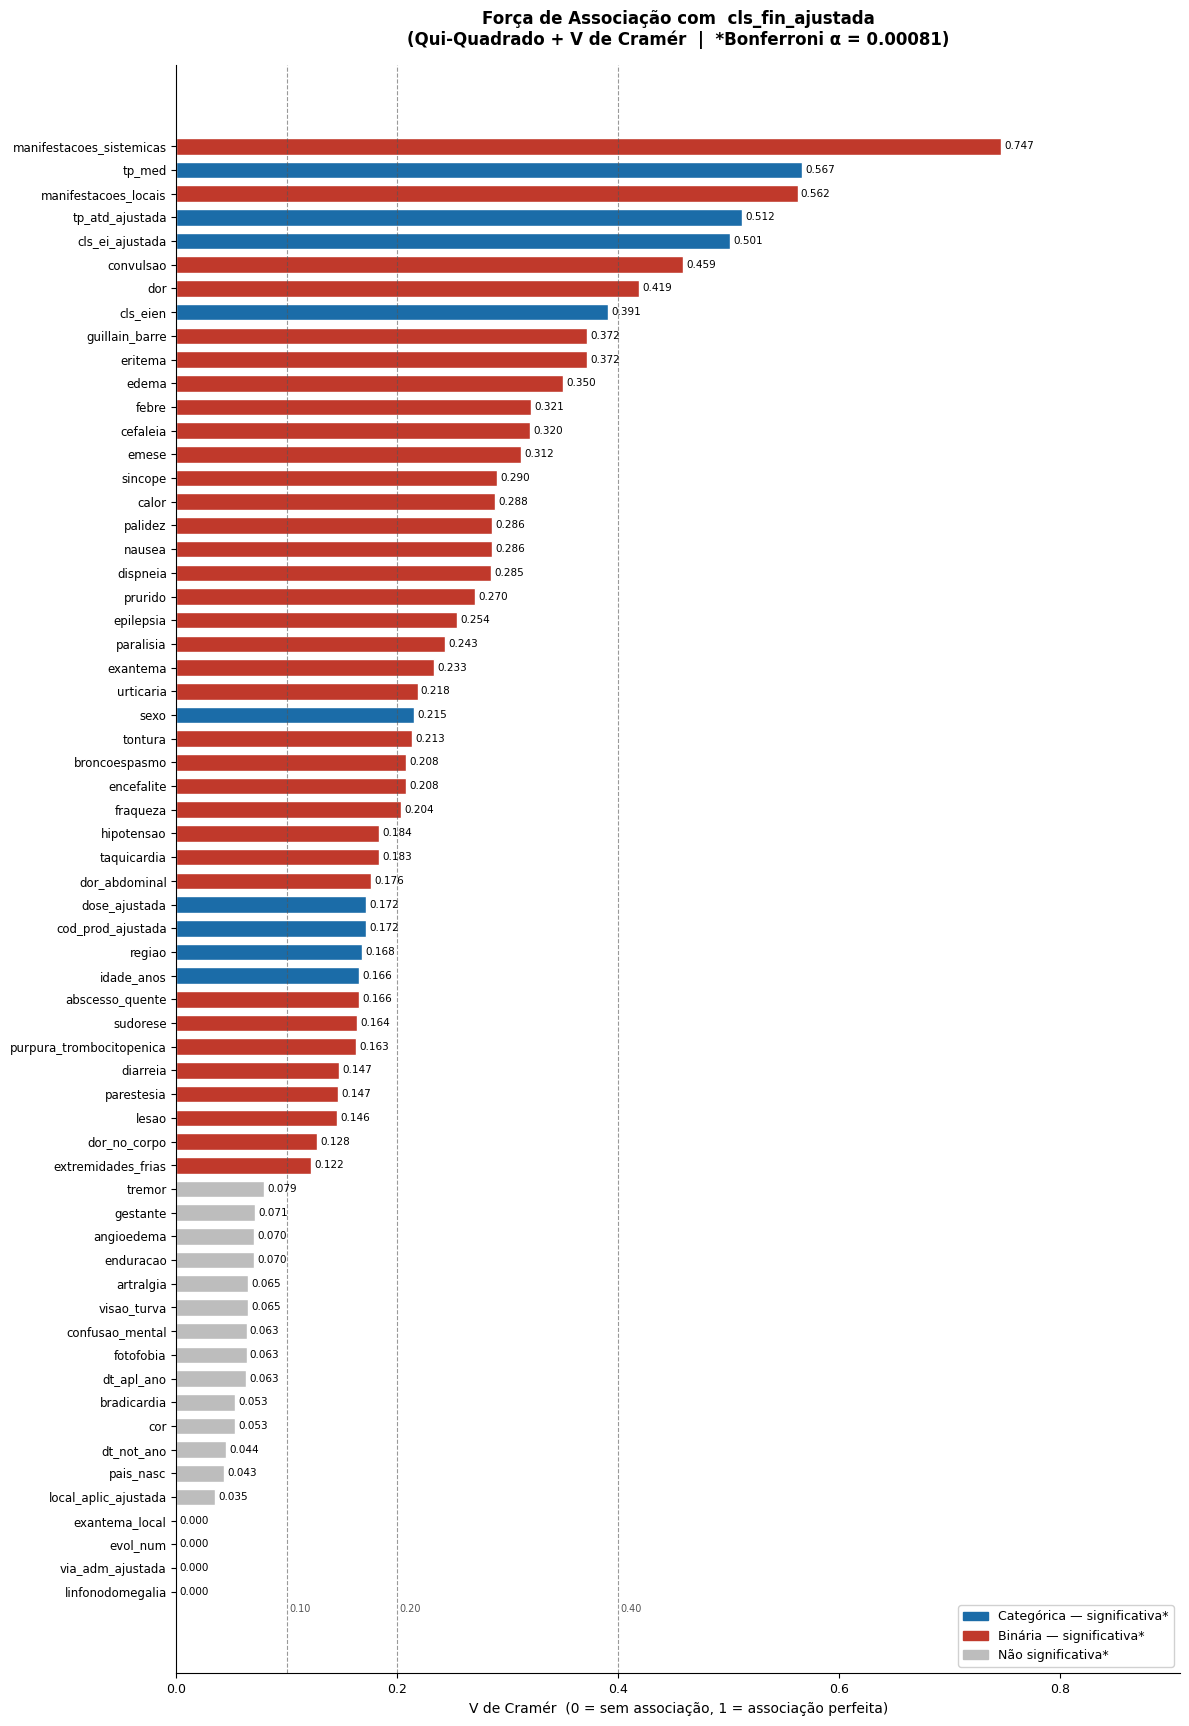


Gráfico salvo em: associacao_cls_fin_ajustada.png


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")
 
# ---------------------------------------------------------------------------
# 0. CARREGAMENTO DOS DADOS
# ---------------------------------------------------------------------------
# Substitua pelo caminho real do seu arquivo
# dados = pd.read_csv("seu_arquivo.csv")
# dados = pd.read_parquet("seu_arquivo.parquet")
 
# ---------------------------------------------------------------------------
# 1. DEFINIÇÃO DAS VARIÁVEIS
# ---------------------------------------------------------------------------
 
coluna_resposta = "cls_fin_ajustada"
 
colunas_categoricas = [
    "dt_not_ano", "regiao", "pais_nasc", "sexo", "cor", "gestante",
    "cod_prod_ajustada", "dt_apl_ano", "dose_ajustada", "via_adm_ajustada",
    "local_aplic_ajustada", "tp_med", "cls_ei_ajustada", "tp_atd_ajustada",
    "cls_eien", "idade_anos", "evol_num"
]
 
colunas_binarias = [
    "dor_abdominal", "dor_no_corpo", "artralgia", "cefaleia", "dor",
    "exantema_local", "exantema", "edema", "eritema", "calor", "enduracao",
    "abscesso_quente", "lesao", "linfonodomegalia", "prurido", "febre",
    "nausea", "emese", "diarreia", "tontura", "sincope", "parestesia",
    "convulsao", "confusao_mental", "fraqueza", "hipotensao", "taquicardia",
    "bradicardia", "extremidades_frias", "palidez", "sudorese", "urticaria",
    "broncoespasmo", "dispneia", "angioedema", "tremor", "fotofobia",
    "visao_turva", "guillain_barre", "encefalite", "epilepsia", "paralisia",
    "purpura_trombocitopenica", "manifestacoes_locais", "manifestacoes_sistemicas"
]
 
# ---------------------------------------------------------------------------
# 2. FUNÇÕES AUXILIARES
# ---------------------------------------------------------------------------
 
def cramers_v(contingency_table):
    """
    Calcula o V de Cramér a partir de uma tabela de contingência.
    Aplica correção de viés (Bergsma & Wicher, 2013).
    Retorna valor entre 0 (sem associação) e 1 (associação perfeita).
    """
    chi2, p, dof, expected = chi2_contingency(contingency_table, correction=False)
    n = contingency_table.values.sum()
    r, k = contingency_table.shape
 
    # Correção de viés
    phi2 = chi2 / n
    phi2_corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    r_corr = r - ((r - 1) ** 2) / (n - 1)
    k_corr = k - ((k - 1) ** 2) / (n - 1)
 
    denom = min(k_corr - 1, r_corr - 1)
    if denom <= 0:
        return chi2, p, dof, 0.0
 
    v = np.sqrt(phi2_corr / denom)
    return chi2, p, dof, round(v, 6)
 
 
def interpretar_cramers_v(v):
    """Referência: Cohen (1988) adaptado para V de Cramér."""
    if v < 0.10:
        return "Negligível"
    elif v < 0.20:
        return "Fraca"
    elif v < 0.40:
        return "Moderada"
    elif v < 0.60:
        return "Forte"
    else:
        return "Muito forte"
 
 
def testar_associacao(df, variavel, resposta, tipo):
    """
    Executa o teste Qui-Quadrado e calcula V de Cramér
    para uma variável em relação à variável resposta.
 
    Parâmetros
    ----------
    df       : DataFrame
    variavel : nome da coluna explicativa
    resposta : nome da coluna resposta
    tipo     : 'categorica' ou 'binaria'
 
    Retorna dict com resultados.
    """
    # Remove linhas com NaN nas duas colunas de interesse
    sub = df[[variavel, resposta]].dropna()
    n_validos = len(sub)
 
    if n_validos < 10:
        return {
            "variavel": variavel,
            "tipo": tipo,
            "n_validos": n_validos,
            "chi2": np.nan,
            "p_valor": np.nan,
            "graus_liberdade": np.nan,
            "cramers_v": np.nan,
            "interpretacao": "Amostras insuficientes",
            "significativo_5pct": False,
        }
 
    # Tabela de contingência
    tabela = pd.crosstab(sub[variavel], sub[resposta])
 
    # Verifica se há células com frequência esperada < 5
    _, _, _, expected = chi2_contingency(tabela, correction=False)
    pct_baixa_freq = (expected < 5).sum() / expected.size
 
    # Roda o teste
    try:
        chi2_stat, p_val, dof, v = cramers_v(tabela)
    except Exception as e:
        return {
            "variavel": variavel,
            "tipo": tipo,
            "n_validos": n_validos,
            "chi2": np.nan,
            "p_valor": np.nan,
            "graus_liberdade": np.nan,
            "cramers_v": np.nan,
            "interpretacao": f"Erro: {e}",
            "significativo_5pct": False,
        }
 
    return {
        "variavel": variavel,
        "tipo": tipo,
        "n_validos": n_validos,
        "chi2": round(chi2_stat, 4),
        "p_valor": round(p_val, 8),
        "graus_liberdade": dof,
        "cramers_v": round(v, 6),
        "interpretacao": interpretar_cramers_v(v),
        "significativo_5pct": p_val < 0.05,
        "aviso_baixa_freq": pct_baixa_freq > 0.20,  # > 20% das células com E < 5
    }
 
 
# ---------------------------------------------------------------------------
# 3. EXECUÇÃO DOS TESTES
# ---------------------------------------------------------------------------
 
print("=" * 65)
print("  ANÁLISE DE ASSOCIAÇÃO: Variáveis × cls_fin_ajustada")
print("=" * 65)
 
resultados = []
 
print("\n[1/2] Testando variáveis CATEGÓRICAS...")
for col in colunas_categoricas:
    if col in df_filtrado.columns:
        res = testar_associacao(df_filtrado, col, coluna_resposta, "Categórica")
        resultados.append(res)
        status = "✓" if res["significativo_5pct"] else "✗"
        print(f"  {status} {col:<35} V={res['cramers_v']:.4f}  p={res['p_valor']:.4e}")
    else:
        print(f"  ! Coluna não encontrada: {col}")
 
print("\n[2/2] Testando variáveis BINÁRIAS...")
for col in colunas_binarias:
    if col in df_filtrado.columns:
        res = testar_associacao(df_filtrado, col, coluna_resposta, "Binária")
        resultados.append(res)
        status = "✓" if res["significativo_5pct"] else "✗"
        print(f"  {status} {col:<40} V={res['cramers_v']:.4f}  p={res['p_valor']:.4e}")
    else:
        print(f"  ! Coluna não encontrada: {col}")
 
# ---------------------------------------------------------------------------
# 4. CORREÇÃO DE BONFERRONI
# ---------------------------------------------------------------------------
 
df_res = pd.DataFrame(resultados).sort_values("cramers_v", ascending=False).reset_index(drop=True)
 
n_testes = df_res["p_valor"].notna().sum()
alpha_bonferroni = 0.05 / n_testes
df_res["significativo_bonferroni"] = df_res["p_valor"] < alpha_bonferroni
 
print(f"\nCorreção de Bonferroni aplicada: α = 0.05 / {n_testes} = {alpha_bonferroni:.6f}")
 
# ---------------------------------------------------------------------------
# 5. RESUMO NO CONSOLE
# ---------------------------------------------------------------------------
 
print("\n" + "=" * 65)
print("  TOP 20 VARIÁVEIS POR V DE CRAMÉR")
print("=" * 65)
print(f"{'Variável':<40} {'V Cramér':>9} {'p-valor':>12} {'Sig.*':>6} {'Força'}")
print("-" * 65)
for _, row in df_res.head(20).iterrows():
    sig = "✓" if row["significativo_bonferroni"] else "✗"
    v_str = f"{row['cramers_v']:.4f}" if pd.notna(row["cramers_v"]) else "   N/A"
    p_str = f"{row['p_valor']:.2e}" if pd.notna(row["p_valor"]) else "      N/A"
    print(f"{row['variavel']:<40} {v_str:>9} {p_str:>12} {sig:>6}   {row['interpretacao']}")
print("* Significativo após correção de Bonferroni")
 
# ---------------------------------------------------------------------------
# 6. GRÁFICO DE BARRAS HORIZONTAIS
# ---------------------------------------------------------------------------
 
df_plot = df_res.dropna(subset=["cramers_v"]).copy()
 
# Paleta por tipo de variável e significância
cores = []
for _, row in df_plot.iterrows():
    if not row["significativo_bonferroni"]:
        cores.append("#BDBDBD")               # cinza — não significativo
    elif row["tipo"] == "Categórica":
        cores.append("#1B6CA8")               # azul — categórica sig.
    else:
        cores.append("#C0392B")               # vermelho — binária sig.
 
fig, ax = plt.subplots(figsize=(12, max(8, len(df_plot) * 0.28)))
 
barras = ax.barh(
    y=df_plot["variavel"],
    width=df_plot["cramers_v"],
    color=cores,
    edgecolor="white",
    height=0.7,
)
 
# Linhas de referência
for limite, label in [(0.10, "0.10"), (0.20, "0.20"), (0.40, "0.40")]:
    ax.axvline(x=limite, color="#555555", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.text(limite + 0.002, len(df_plot) - 0.5, label,
            fontsize=7, color="#555555", va="top")
 
# Valores nas barras
for bar, (_, row) in zip(barras, df_plot.iterrows()):
    v = row["cramers_v"]
    ax.text(v + 0.003, bar.get_y() + bar.get_height() / 2,
            f"{v:.3f}", va="center", ha="left", fontsize=7.5)
 
# Legenda manual
patches_legenda = [
    mpatches.Patch(color="#1B6CA8", label="Categórica — significativa*"),
    mpatches.Patch(color="#C0392B", label="Binária — significativa*"),
    mpatches.Patch(color="#BDBDBD", label="Não significativa*"),
]
ax.legend(handles=patches_legenda, loc="lower right", fontsize=9, framealpha=0.9)
 
ax.set_xlabel("V de Cramér  (0 = sem associação, 1 = associação perfeita)", fontsize=10)
ax.set_title(
    f"Força de Associação com  cls_fin_ajustada\n"
    f"(Qui-Quadrado + V de Cramér  |  *Bonferroni α = {alpha_bonferroni:.5f})",
    fontsize=12, fontweight="bold", pad=14
)
ax.invert_yaxis()
ax.set_xlim(0, df_plot["cramers_v"].max() * 1.15 + 0.05)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="y", labelsize=8.5)
ax.tick_params(axis="x", labelsize=9)
 
plt.tight_layout()
plt.show()
 